In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from zipfile import ZipFile
with ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("olist_data")

#Data Cleaning

##Load the CSV files

In [13]:
customers = pd.read_csv("olist_data/olist_customers_dataset.csv")
orders = pd.read_csv("olist_data/olist_orders_dataset.csv")
order_items = pd.read_csv("olist_data/olist_order_items_dataset.csv")
products = pd.read_csv("olist_data/olist_products_dataset.csv")
reviews = pd.read_csv("olist_data/olist_order_reviews_dataset.csv")
payments = pd.read_csv("olist_data/olist_order_payments_dataset.csv")
sellers = pd.read_csv("olist_data/olist_sellers_dataset.csv")
translation = pd.read_csv("olist_data/product_category_name_translation.csv")

##check for missing values

In [14]:
customers.isnull().sum()
orders.isnull().sum()
order_items.isnull().sum()
products.isnull().sum()
reviews.isnull().sum()
payments.isnull().sum()
sellers.isnull().sum()

,0
seller_id,0
seller_zip_code_prefix,0
seller_city,0
seller_state,0


### Missing Values

Checked all datasets for missing values using `isnull().sum()`. Missing values were not found in the  datasets.

##fix data types

In [15]:
customers.info()
orders.info()
order_items.info()
products.info()
reviews.info()
payments.info()
sellers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4

In [16]:
orders["order_purchase_timestamp"] = pd.to_datetime(orders["order_purchase_timestamp"])
orders["order_approved_at"] = pd.to_datetime(orders["order_approved_at"])
orders["order_delivered_carrier_date"] = pd.to_datetime(orders["order_delivered_carrier_date"])
orders["order_delivered_customer_date"] = pd.to_datetime(orders["order_delivered_customer_date"])
orders["order_estimated_delivery_date"] = pd.to_datetime(orders["order_estimated_delivery_date"])
order_items["shipping_limit_date"] = pd.to_datetime(order_items["shipping_limit_date"])
reviews["review_creation_date"] = pd.to_datetime(reviews["review_creation_date"])
reviews["review_answer_timestamp"] = pd.to_datetime(reviews["review_answer_timestamp"])
orders.info()
order_items.info()
reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype     

### Data Type Conversion

Converted all date columns from `object` to `datetime` format to enable time-based analysis.

##remove duplicates

In [17]:
customers.duplicated().sum()
orders.duplicated().sum()
order_items.duplicated().sum()
products.duplicated().sum()
reviews.duplicated().sum()
payments.duplicated().sum()
sellers.duplicated().sum()

np.int64(0)

### Duplicate Records

Checked all datasets for duplicate records. No duplicate rows were found, so no records were removed.

##merge relevant tables.

In [18]:
df = pd.merge(orders, customers, on="customer_id", how="left")
df = pd.merge(df, order_items, on="order_id", how="left")
df = pd.merge(df, products, on="product_id", how="left")
df = pd.merge(df, translation, on="product_category_name", how="left")
df = pd.merge(df, reviews, on="order_id", how="left")
df = pd.merge(df, payments, on="order_id", how="left")
df = pd.merge(df, sellers, on="seller_id", how="left")
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,review_comment_message,review_creation_date,review_answer_timestamp,payment_sequential,payment_type,payment_installments,payment_value,seller_zip_code_prefix,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,1.0,credit_card,1.0,18.12,9350.0,maua,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,3.0,voucher,1.0,2.00,9350.0,maua,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,7c396fd4830fd04220f754e42b4e5bff,3149,...,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,2.0,voucher,1.0,18.59,9350.0,maua,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,af07308b275d755c9edb36a90c618231,47813,...,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,1.0,boleto,1.0,141.46,31570.0,belo horizonte,SP
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,3a653a41f6f9fc3d2a113cf8398680e8,75265,...,NaN,2018-08-18,2018-08-22 19:07:58,1.0,credit_card,3.0,179.12,14840.0,guariba,SP


In [19]:
df.shape


(119143, 40)

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 40 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   customer_unique_id             119143 non-null  object        
 9   customer_zip_code_prefix       119143 non-null  int64         
 10  customer_city                  119143 non-null  object        
 11  

### Dataset Merging

Merged the datasets using common keys (`customer_id`, `order_id`, `product_id`, and `seller_id`) to create a single dataset for analysis.

#  Sales Analysis AND Visualisations

## Which product category has the highest revenue?

In [27]:
revenue_by_category = (df.groupby("product_category_name_english")["price"].sum().sort_values(ascending=False))
revenue_by_category#.head(10)

,price
product_category_name_english,
health_beauty,1301947.97
watches_gifts,1254322.95
bed_bath_table,1107249.09
sports_leisure,1029603.88
computers_accessories,950053.69
...,...
flowers,1110.04
home_comfort_2,773.17
cds_dvds_musicals,730.00


The health_beauty category generated the highest revenue (1,301,947.97), making it the top-performing product category.

### bar chart (revenue by category)

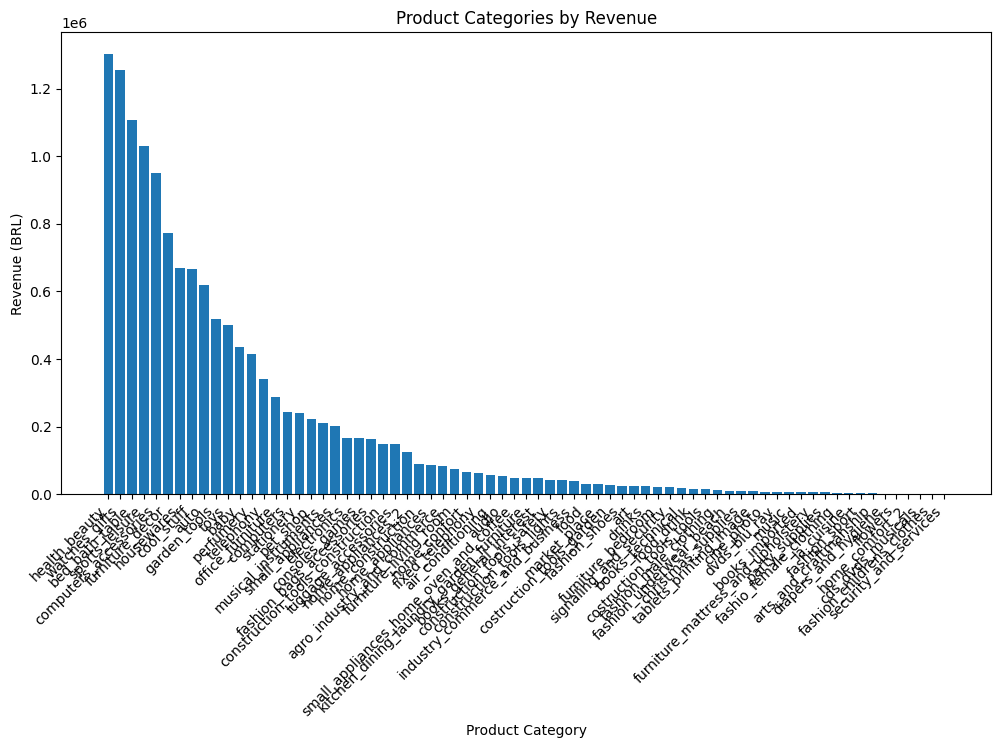

In [26]:
top10 = revenue_by_category#.head(10)
plt.figure(figsize=(12,6))
plt.bar(top10.index, top10.values)
plt.title("Product Categories by Revenue")
plt.xlabel("Product Category")
plt.ylabel("Revenue (BRL)")
plt.xticks(rotation=45, ha="right")
plt.show()

## Which month had peak sales?

In [34]:
df["month"] = df["order_purchase_timestamp"].dt.month_name()
monthly_sales = df.groupby("month")["price"].sum().sort_values(ascending=False)
monthly_sales

,price
month,
May,1581926.26
August,1490758.50
July,1464308.34
March,1427707.11
April,1424312.98
June,1366920.50
February,1151526.15
January,1123596.81
November,1055072.10


May had the highest sales, with total revenue of 1,581,926.26 BRL.

###line chart (monthly trend)

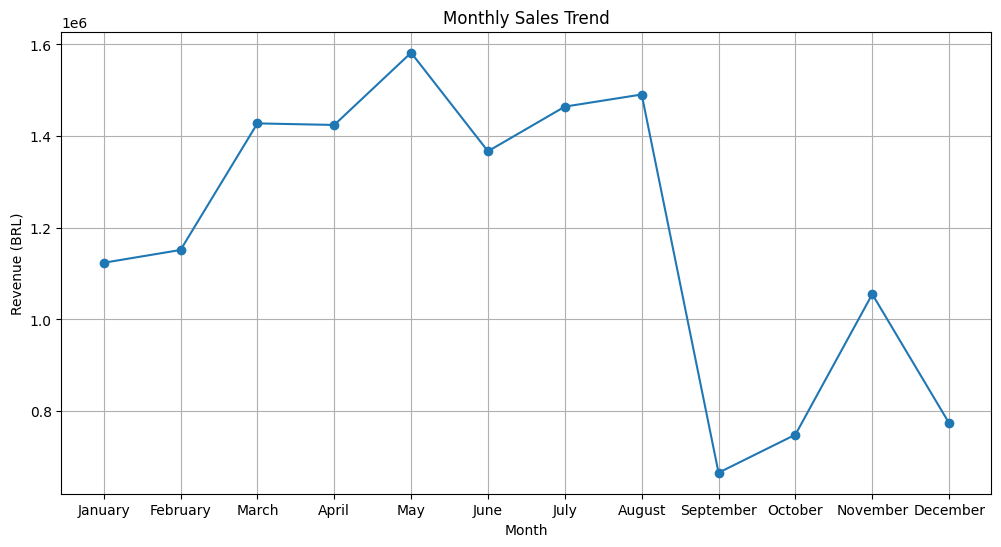

In [36]:
df["month_num"] = df["order_purchase_timestamp"].dt.month
df["month"] = df["order_purchase_timestamp"].dt.month_name()
monthly_sales = (df.groupby(["month_num", "month"])["price"].sum().reset_index().sort_values("month_num"))
plt.figure(figsize=(12,6))
plt.plot(monthly_sales["month"], monthly_sales["price"], marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (BRL)")
plt.grid(True)
plt.show()

## Which region performs best?

In [48]:
regional_sales = (df.groupby("customer_state")["price"].sum().sort_values(ascending=False))
regional_sales

,price
customer_state,
SP,5477008.74
RJ,1921752.53
MG,1645847.27
RS,791716.84
PR,708794.22
BA,543243.99
SC,539896.20
DF,315122.29
GO,313198.27


São Paulo (SP) generated the highest revenue among all customer states, making it the best-performing region.

###Create the bar chart

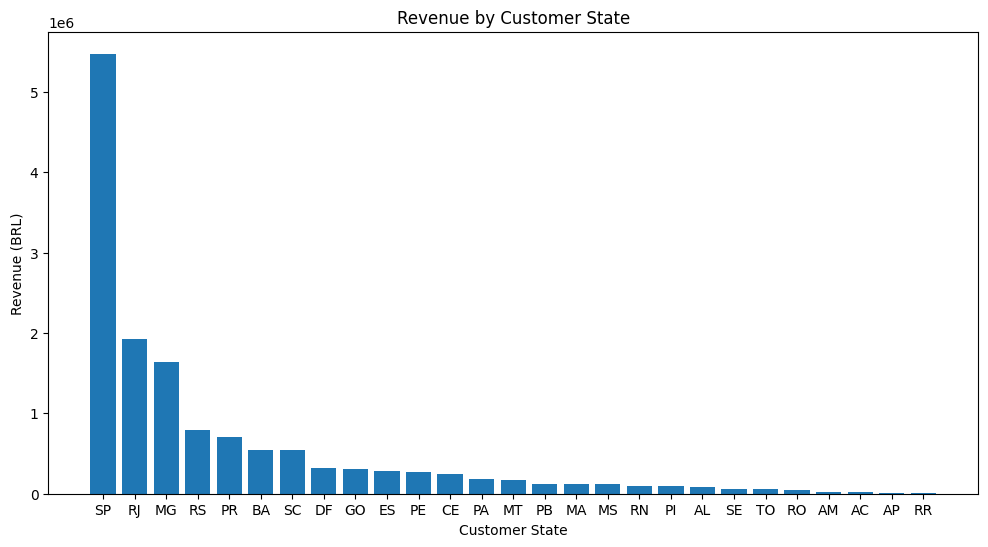

In [49]:
plt.figure(figsize=(12,6))
plt.bar(regional_sales.index,regional_sales.values)
plt.title("Revenue by Customer State")
plt.xlabel("Customer State")
plt.ylabel("Revenue (BRL)")
plt.show()

## What is the average order value trend?

In [50]:
avg_order_value = (df.groupby(["month_num", "month"])["price"].mean().reset_index().sort_values("month_num"))
avg_order_value

,month_num,month,price
0,1,January,116.725204
1,2,February,114.068960
2,3,March,121.063946
3,4,April,127.901668
4,5,May,124.796960
5,6,June,121.850642
6,7,July,119.603720
7,8,August,117.493577
8,9,September,129.391355
9,10,October,124.712802


The average order value fluctuated throughout the year. September recorded the highest average order value (approximately 129 BRL), while February had the lowest average order value. This indicates that customers tended to place higher-value orders during certain months rather than consistently throughout the year.

###Create the line chart

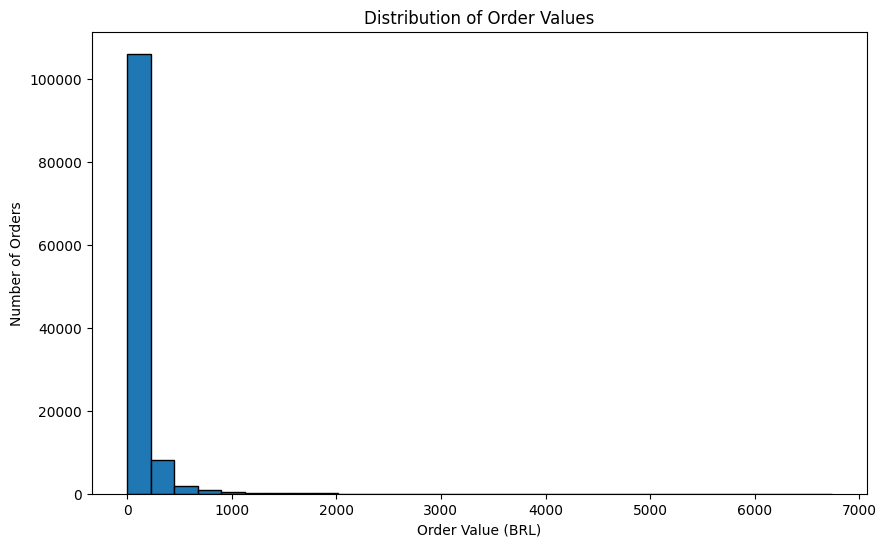

In [52]:
plt.figure(figsize=(10,6))
plt.hist(df["price"].dropna(), bins=30, edgecolor="black")
plt.title("Distribution of Order Values")
plt.xlabel("Order Value (BRL)")
plt.ylabel("Number of Orders")
plt.show()

The distribution of order values is highly right-skewed. Most orders have relatively low values (below 1000 BRL), while only a small number of orders have very high values. This indicates that the business primarily receives low- to medium-value purchases, with a few expensive orders acting as outliers..

## What is the customer review score distribution?

In [54]:
review_distribution = (df["review_score"].value_counts().sort_index())
review_distribution

,count
review_score,
1.0,15428
2.0,4162
3.0,9894
4.0,22319
5.0,66343


###Create the pie chart

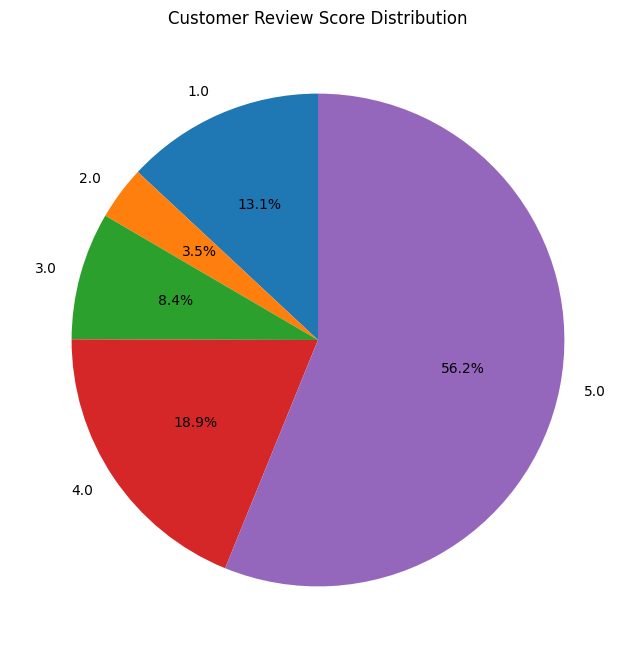

In [55]:
plt.figure(figsize=(8,8))
plt.pie(review_distribution.values,labels=review_distribution.index,autopct="%1.1f%%",startangle=90)
plt.title("Customer Review Score Distribution")
plt.show()

More than half of the customers (56.2%) gave a 5-star rating, indicating a high level of customer satisfaction. Only 3.5% of customers gave 2-star ratings, while 13.1% gave 1-star ratings, suggesting that negative reviews are relatively less common.

##Heatmap (Category vs Month)

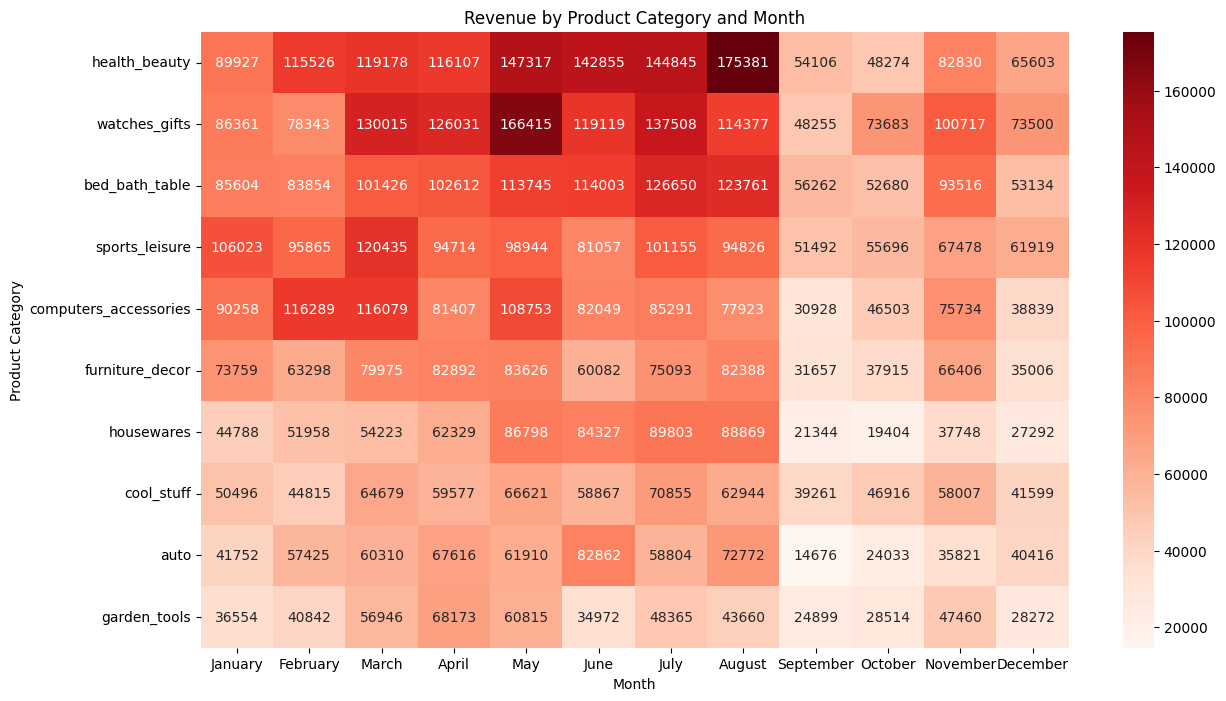

In [57]:
heatmap_data = (df.pivot_table(values="price",index="product_category_name_english",columns="month",aggfunc="sum"))
heatmap_data.head()
month_order = ["January", "February", "March", "April","May", "June", "July", "August","September", "October", "November", "December"]
heatmap_data = heatmap_data[month_order]
top_categories = revenue_by_category.head(10).index
heatmap_data = heatmap_data.loc[top_categories]
plt.figure(figsize=(14,8))
sns.heatmap(heatmap_data,cmap="Reds",annot=True,fmt=".0f")
plt.title("Revenue by Product Category and Month")
plt.xlabel("Month")
plt.ylabel("Product Category")
plt.show()

The heatmap shows that the Health & Beauty category consistently generated high revenue throughout the year, with the highest sales observed in August. Most product categories experienced stronger sales between March and August, while revenue generally declined during September and October. This visualization highlights seasonal trends and identifies the best-performing product categories.

In [58]:
df.to_csv("olist_final_dataset.csv", index=False)
from google.colab import files
files.download("olist_final_dataset.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Business Insights Report

### 1. Health & Beauty is the Highest Revenue-Generating Category

**Finding:** The **Revenue by Product Category** chart shows that **Health & Beauty** generated the highest revenue among all product categories, followed by Watches & Gifts and Bed Bath Table.

**Business Recommendation:** Increase inventory, marketing campaigns, and promotional offers for Health & Beauty products. Cross-selling related products can further improve revenue.

---

### 2. May Recorded the Highest Monthly Sales

**Finding:** The **Monthly Sales Trend** chart indicates that **May** had the highest sales revenue compared to the other months.

**Business Recommendation:** Plan major promotional campaigns, product launches, and stock replenishment before May to maximize sales during this high-demand period.

---

### 3. São Paulo (SP) is the Best Performing Region

**Finding:** The **Regional Sales** chart shows that **São Paulo (SP)** contributes the highest sales revenue, followed by Rio de Janeiro (RJ) and Minas Gerais (MG).

**Business Recommendation:** Continue investing in marketing and logistics in SP while expanding targeted campaigns in other states to increase market penetration.

---

### 4. Customers are Highly Satisfied with Their Purchases

**Finding:** The **Customer Review Score Distribution** chart reveals that the majority of customers gave **5-star ratings**, indicating a high level of customer satisfaction.

**Business Recommendation:** Maintain product quality and delivery standards. Encourage satisfied customers to leave reviews and implement loyalty programs to improve customer retention.

---

### 5. Revenue is Concentrated in a Few Product Categories

**Finding:** The **Revenue by Product Category** chart shows that a small number of product categories contribute a significant share of total revenue, while many categories generate comparatively lower sales.

**Business Recommendation:** Continue strengthening high-performing categories while analyzing low-performing categories to determine whether they need better marketing, pricing adjustments, or product assortment improvements.
